<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/MeanShiftClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift , estimate_bandwidth
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler


In [3]:
X , _ = make_blobs(n_samples = 600 , centers = 4 , cluster_std = 0.92 , random_state = 0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)
bandwidth = estimate_bandwidth(X_scaled , quantile = 0.2 , n_samples=600)
print(bandwidth)

[[ 0.89517969 -1.27236033]
 [-0.62437853  1.59306334]
 [ 0.30309095 -1.64062501]
 ...
 [-0.26056239 -0.91086692]
 [ 0.36453271  0.18081872]
 [ 0.04943236 -1.07285651]]
0.9245534130117229


In [4]:
ms = MeanShift(bandwidth = bandwidth , bin_seeding = True)
ms.fit(X_scaled)

MeanShift(bandwidth=np.float64(0.9245534130117229), bin_seeding=True)

In [6]:
labels = ms.labels_
centers_scaled = ms.cluster_centers_
print(labels)
print(centers_scaled)

[3 2 3 3 2 1 0 0 0 1 3 2 0 3 0 1 3 1 3 1 1 1 2 1 1 0 3 1 0 2 0 0 3 3 0 3 3
 3 0 0 3 1 2 0 1 0 3 1 3 3 1 0 3 0 2 1 2 1 1 2 3 0 0 2 3 2 1 0 1 0 2 2 3 1
 0 3 3 0 2 3 0 2 1 3 0 3 3 0 2 3 0 2 3 1 3 0 2 0 3 1 2 2 3 0 2 3 2 1 1 2 1
 2 0 2 0 0 1 0 3 3 0 1 1 1 2 2 0 1 3 3 1 1 1 0 0 3 0 0 2 1 2 3 2 3 1 1 1 2
 3 0 1 2 3 0 2 3 1 2 2 0 3 1 3 3 1 3 3 3 2 1 3 0 1 3 3 2 1 2 2 0 2 0 0 2 2
 0 1 2 2 1 0 3 0 2 0 2 0 0 3 2 3 2 0 3 1 1 1 1 1 1 2 2 0 3 1 3 2 0 0 3 2 3
 0 1 0 3 1 2 2 1 2 3 0 0 3 1 0 3 0 1 3 3 3 2 3 1 2 0 1 2 2 1 1 3 2 3 1 2 0
 1 3 2 3 1 3 3 2 2 1 1 2 3 1 2 2 3 2 1 1 1 1 1 2 1 1 3 3 0 3 0 1 3 0 3 3 2
 3 3 1 1 2 3 2 2 1 0 1 3 2 1 1 2 1 1 3 3 1 2 3 0 2 2 3 1 3 0 1 0 0 1 1 2 1
 0 0 2 3 0 2 3 1 2 2 1 0 0 1 2 3 3 3 1 2 2 1 3 0 2 3 0 2 2 2 1 2 3 2 0 1 0
 2 2 3 1 0 3 1 2 2 0 2 1 0 0 1 1 1 2 2 3 3 3 3 0 3 3 0 0 0 1 2 0 2 2 0 1 3
 1 0 3 0 1 1 0 2 2 2 0 3 1 2 1 3 2 3 1 0 2 3 3 3 1 2 0 3 3 0 0 0 1 3 3 3 3
 0 2 1 2 0 1 0 3 1 1 0 3 0 1 1 2 1 1 3 0 0 3 1 2 3 3 3 0 0 2 1 0 1 3 2 0 3
 2 1 2 0 2 1 2 3 2 0 3 1 

In [7]:
#Convert centers back
centers = scaler.inverse_transform(centers_scaled)
print(centers)

[[ 0.64417506  4.20266187]
 [-1.27524111  3.0091003 ]
 [-1.05981168  7.78936083]
 [ 1.90810489  0.98312534]]


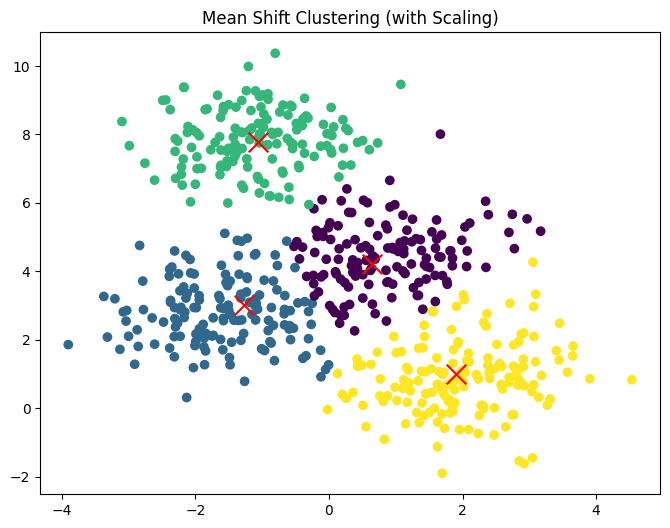

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], color='red', marker='x', s=200)
plt.title("Mean Shift Clustering (with Scaling)")
plt.show()